### Autoregressive (AR) HMM Demo

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [27]:
sns.set_style("white")

color_names = [
    "windows blue",
    "red",
    "amber",
    "faded green",
    "dusty purple",
    "orange",
    "brown",
    "pink"
]

colors = sns.xkcd_palette(color_names)
cmap = gradient_cmap(colors)

### Manually construct an ARHMM

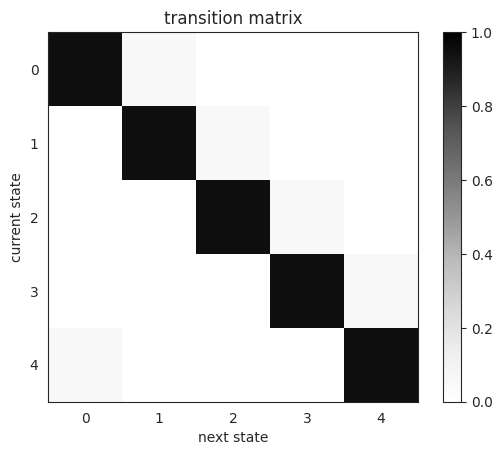

In [28]:
# Make a transition matrix
num_states = 5
transition_probs = (jnp.arange(num_states)**10).astype(float)
transition_probs /= transition_probs.sum()
transition_matrix = jnp.zeros((num_states, num_states))
for k, p in enumerate(transition_probs[::-1]):
    transition_matrix += jnp.roll(p * jnp.eye(num_states), k, axis=1) # roll = shift diagonal by k (wrap around the last k values to the front)
    
plt.imshow(transition_matrix, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("transition matrix")
plt.colorbar()

### Construct and plot the autoregressive dynamics distributions (setting a ground truth)

In [29]:
# Make emission distributions
emission_dim = 2
num_lags = 1 # how many past time steps used for the autoregressive part of the model

keys = jr.split(jr.PRNGKey(0), num_states)
angles = jnp.linspace(0, 2 * jnp.pi, num_states, endpoint=False)
theta = jnp.pi / 25 # rotational frequency
weights = jnp.array([0.8 * random_rotation(key, emission_dim, theta=theta) for key in keys])
biases = jnp.column_stack([jnp.cos(angles), jnp.sin(angles), jnp.zeros((num_states, emission_dim - 2))])
covariances = jnp.tile(0.001 * jnp.eye(emission_dim), (num_states, 1, 1))

# Compute the stationary points
stationary_points = jax.vmap(jnp.linalg.solve)(jnp.eye(emission_dim) - weights, biases)

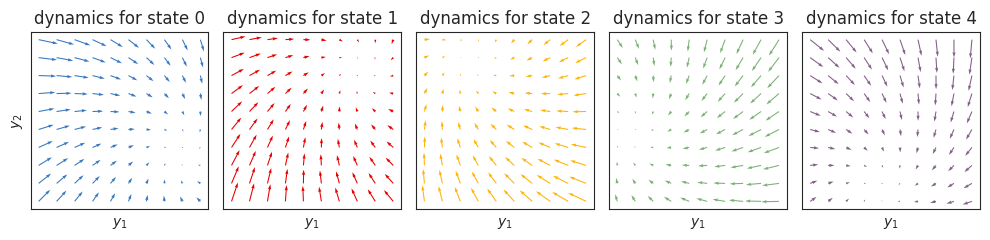

In [30]:
if emission_dim == 2:
    lim = 5
    x = jnp.linspace(-lim, lim, 10)
    y = jnp.linspace(-lim, lim, 10)
    X, Y = jnp.meshgrid(x, y)
    xy = jnp.column_stack((X.ravel(), Y.ravel()))

    fig, axs = plt.subplots(1, num_states, figsize=(2 * num_states, 4))
    for k in range(num_states):
        A, b = weights[k], biases[k]
        dxydt_m = xy.dot(A.T) + b - xy
        axs[k].quiver(xy[:, 0], xy[:, 1],
                    dxydt_m[:, 0], dxydt_m[:, 1],
                    color=colors[k % len(colors)])

        
        axs[k].set_xlabel('$y_1$')
        axs[k].set_xticks([])
        if k == 0:
            axs[k].set_ylabel("$y_2$")
        axs[k].set_yticks([])
        axs[k].set_aspect("equal")
        axs[k].set_title(f"dynamics for state {k}")
                        

    plt.tight_layout()

### Sample emissions from the ARHMM (for one sequence)

In [39]:
# Make an Autoregressive (AR) HMM
true_arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
true_params, _ = true_arhmm.initialize(initial_probs=jnp.ones(num_states) / num_states,
                                       transition_matrix=transition_matrix,
                                       emission_weights=weights,
                                       emission_biases=biases,
                                       emission_covariances=covariances)

time_bins = 10000
true_states, emissions = true_arhmm.sample(true_params, jr.PRNGKey(0), time_bins)

# Compute the lagged emissions (aka inputs)
inputs = true_arhmm.compute_inputs(emissions)

In [40]:
print(f"emissions.shape = {emissions.shape} = (time_bins, emission_dim)")
print(f"inputs.shape = {inputs.shape} = (time_bins, input_dim)")

emissions.shape = (10000, 2) = (time_bins, emission_dim)
inputs.shape = (10000, 2) = (time_bins, input_dim)


Text(0.5, 1.0, 'Sampled trajectory from an AR-HMM, color-coded by discrete state')

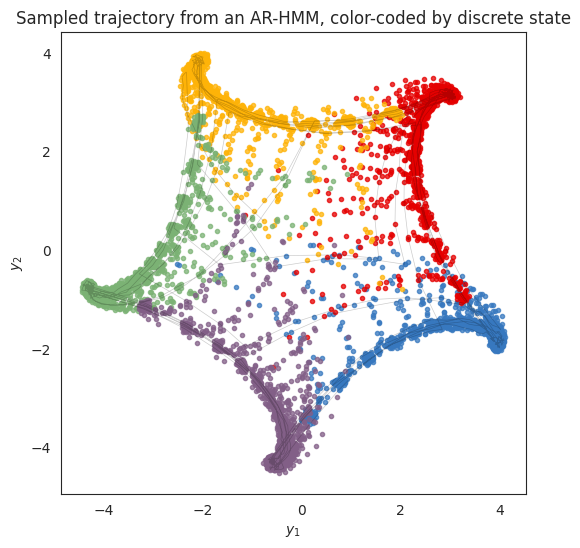

In [41]:
# Plot the sampled data
fig = plt.figure(figsize=(6, 6))
for k in range(num_states):
    plt.plot(*emissions[true_states==k].T, 'o', color=colors[k],
         alpha=0.75, markersize=3)
    
plt.plot(*emissions[:1000].T, '-k', lw=0.5, alpha=0.2)
plt.xlabel("$y_1$")
plt.ylabel("$y_2$")
plt.title("Sampled trajectory from an AR-HMM, color-coded by discrete state")

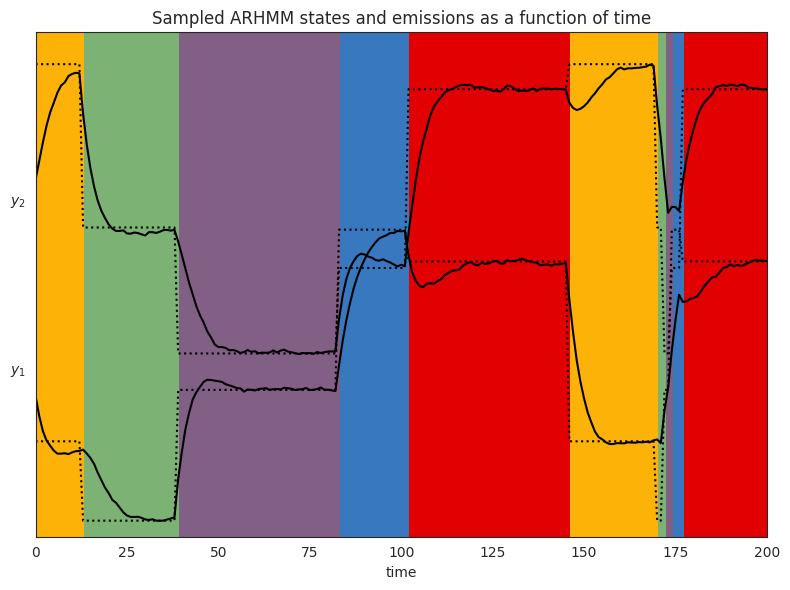

In [42]:
# Plot the emissions and the smoothed emissions
plot_slice = (0, 200)
lim = 1.05 * abs(emissions).max()
plt.figure(figsize=(8, 6))
plt.imshow(true_states[None, :],
           aspect="auto",
           cmap=cmap,
           vmin=0,
           vmax=len(colors)-1,
           extent=(0, time_bins, -lim, (emission_dim)*lim))


Ey = jnp.array(stationary_points)[true_states]
for d in range(emission_dim):
    plt.plot(emissions[:,d] + lim * d, '-k')
    plt.plot(Ey[:,d] + lim * d, ':k')

plt.xlim(plot_slice)
plt.xlabel("time")
plt.yticks(lim * jnp.arange(emission_dim), ["$y_{{{}}}$".format(d+1) for d in range(emission_dim)])
plt.title("Sampled ARHMM states and emissions as a function of time")
plt.tight_layout()

### Fit an ARHMM

In [43]:
# Now fit an HMM to the emissions
key1, key2 = jr.split(jr.PRNGKey(0), 2)
test_num_states = num_states

# Initialize with K-Means
arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions)

# Fit with EM (gets the parameters and the log probabilities at each iteration; lps = marginal log-likelihood at each iteration - should be non-decreasing))
fitted_params, lps = arhmm.fit_em(params, props, emissions, inputs=inputs)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;00:00]</div>

In [44]:
print(f"emission_dim: {emission_dim}")
print(f"emissions: {emissions.shape}")
print(f"inputs: {inputs.shape}")

emission_dim: 2
emissions: (10000, 2)
inputs: (10000, 2)


In [45]:
# time_bins = 12
# true_states, emissions = true_arhmm.sample(true_params, jr.PRNGKey(0), time_bins)

# print(f"true_states: {true_states.shape}")
# print(f"emissions: {emissions.shape}")

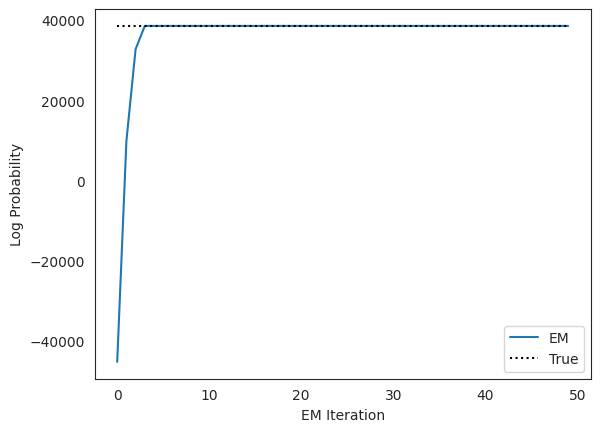

In [46]:
true_lp = true_arhmm.marginal_log_prob(true_params, emissions, inputs=inputs)
plt.plot(lps, label="EM")
plt.plot(true_lp * jnp.ones(len(lps)), ':k', label="True")
plt.xlabel("EM Iteration")
plt.ylabel("Log Probability")
plt.legend(loc="lower right")
plt.show()

In [48]:
# Compute the posterior distribution of the latent states
posterior = arhmm.smoother(fitted_params, emissions, inputs=inputs)
posterior.smoothed_probs.T

Array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [52]:
#print(f"fitted_params.shape: {fitted_params.shape}")
print(f"emissions.shape: {emissions.shape}")
print(f"inputs.shape: {inputs.shape}")

emissions.shape: (10000, 2)
inputs.shape: (10000, 2)


Text(0.5, 0, 'time')

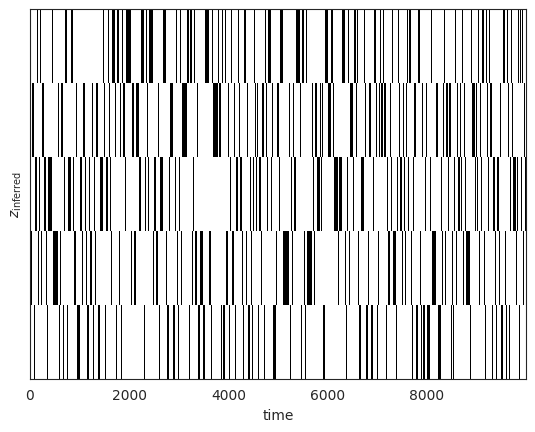

In [49]:
plt.imshow(posterior.smoothed_probs.T, aspect="auto", interpolation="none", cmap="Greys", vmin=0, vmax=1)
plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")
